# Simulation de la régulation du safran sur le voilier 1M

In [25]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

### Coefficients d'un régulateur PID ainsi que dt, la période d'échantillonnage

$$
dt = \frac{1}{samplingFrequency}
$$

In [26]:
# Paramètres du régulateur PID
Kp = 10.0   # Gain proportionnel
Ki = 0.1   # Gain intégral
Kd = 0   # Gain dérivé
dt = 0.1   # Période d'échantillonnage (en secondes)

### Paramètres de simulation du voilier 1M

In [27]:
# Paramètres du voilier
cap_consigne = 90.0          # Cap cible (en degrés)
cap_actuel = 0.0             # Cap initial (en degrés)
angle_safran = 0.0           # Angle initial du safran (en degrés)

inertie_voilier = 0.9        # Facteur d'inertie du voilier (entre 0 et 1)

somme_erreurs = 0.0          # Accumulation des erreurs (terme intégral)
erreur_precedente = 0.0      # Erreur précédente pour le terme dérivé

### Paramètres propres à la simulation

In [28]:
# Simulation
temps_simulation = 50        # Temps total de simulation (en secondes)
n_iterations = int(temps_simulation / dt)
caps = []                    # Liste pour enregistrer les caps au cours du temps
safran_angles = []           # Liste pour enregistrer les angles du safran
temps = []                   # Liste pour enregistrer les timestamps

## Simulation

In [29]:
# Boucle de simulation
for t in range(n_iterations):
    # Calcul de l'erreur
    erreur = cap_consigne - cap_actuel
    if erreur > 180:
        erreur -= 360
    elif erreur < -180:
        erreur += 360

    # Terme proportionnel
    P = Kp * erreur

    # Terme intégral
    somme_erreurs += erreur * dt
    I = Ki * somme_erreurs

    # Terme dérivé
    D = Kd * (erreur - erreur_precedente) / dt

    # Calcul de la sortie PID
    angle_safran = P + I + D

    # Limitation de l'angle du safran (-45° à +45°)
    angle_safran = max(-45, min(45, angle_safran))

    # Mise à jour du cap (modèle simple avec inertie)
    cap_actuel += (angle_safran - cap_actuel * (1 - inertie_voilier)) * dt
    cap_actuel = cap_actuel % 360  # Assure que le cap reste dans [0, 360]

    # Sauvegarde des données pour analyse
    caps.append(cap_actuel)
    safran_angles.append(angle_safran)
    temps.append(t * dt)

    # Mise à jour de l'erreur précédente
    erreur_precedente = erreur

## Affichage des résultats

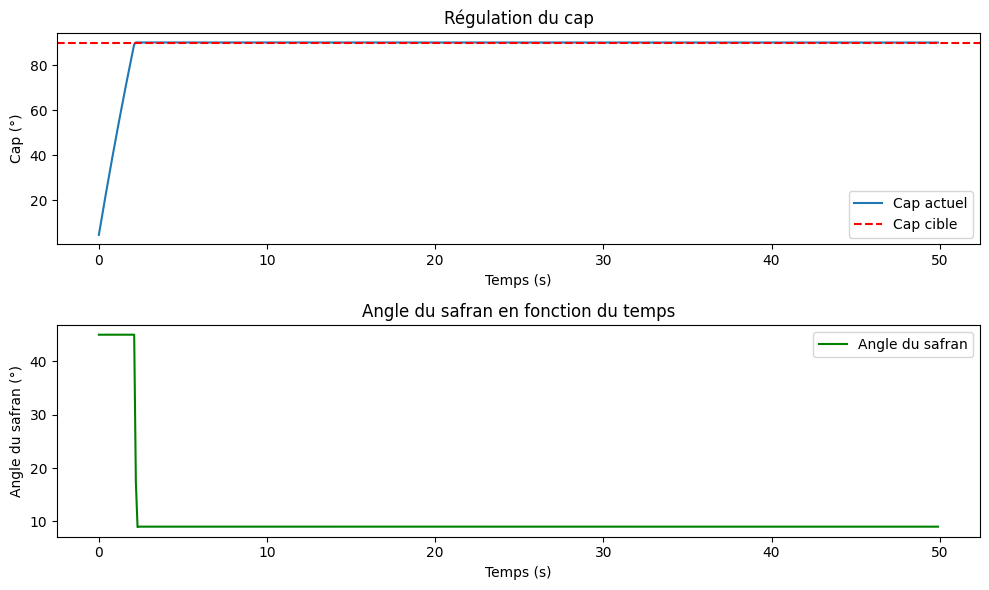

In [30]:
# Affichage des résultats
plt.figure(figsize=(10, 6))

# Graphique du cap
plt.subplot(2, 1, 1)
plt.plot(temps, caps, label="Cap actuel")
plt.axhline(y=cap_consigne, color="r", linestyle="--", label="Cap cible")
plt.xlabel("Temps (s)")
plt.ylabel("Cap (°)")
plt.legend()
plt.title("Régulation du cap")

# Graphique de l'angle du safran
plt.subplot(2, 1, 2)
plt.plot(temps, safran_angles, label="Angle du safran", color="g")
plt.xlabel("Temps (s)")
plt.ylabel("Angle du safran (°)")
plt.legend()
plt.title("Angle du safran en fonction du temps")

plt.tight_layout()
plt.show()